* Author: Sameer Kesava
* email: sameervk.iitkgp@gmail.com

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from datetime import datetime, timedelta

# Import data

In [3]:
file_path = "/home/sameervk/Documents/wind-price-dataset-1-2.csv"

In [4]:
df = pd.read_csv(file_path, parse_dates = ['UtcDatetime'])

In [5]:
df.head(10)

,UtcDatetime,Price,Volume_MWh
0,2019-01-01 00:00:00,60.12,14.889867
1,2019-01-01 01:00:00,55.76,14.162405
2,2019-01-01 02:00:00,46.23,13.943371
3,2019-01-01 03:00:00,44.10,13.288542
4,2019-01-01 04:00:00,44.41,10.449148
5,2019-01-01 05:00:00,46.03,10.864678
6,2019-01-01 06:00:00,51.00,10.568561
7,2019-01-01 07:00:00,39.00,10.953883
8,2019-01-01 08:00:00,44.17,11.250852
9,2019-01-01 09:00:00,51.30,11.371023


In [6]:
df.tail(10)

,UtcDatetime,Price,Volume_MWh
37237,2023-04-01 13:00:00,93.09,8.523011
37238,2023-04-01 14:00:00,95.40,7.280114
37239,2023-04-01 15:00:00,104.32,9.103030
37240,2023-04-01 16:00:00,124.99,9.020170
37241,2023-04-01 17:00:00,136.64,7.421780
37242,2023-04-01 18:00:00,131.64,4.689678
37243,2023-04-01 19:00:00,121.29,4.929261
37244,2023-04-01 20:00:00,104.99,4.860133
37245,2023-04-01 21:00:00,95.01,4.364394
37246,2023-04-01 22:00:00,114.76,3.992519


# Exploratory Data Analysis

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37247 entries, 0 to 37246
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   UtcDatetime  37247 non-null  datetime64[ns]
 1   Price        37199 non-null  float64       
 2   Volume_MWh   37202 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 873.1 KB


## PLOT 1: PRICE

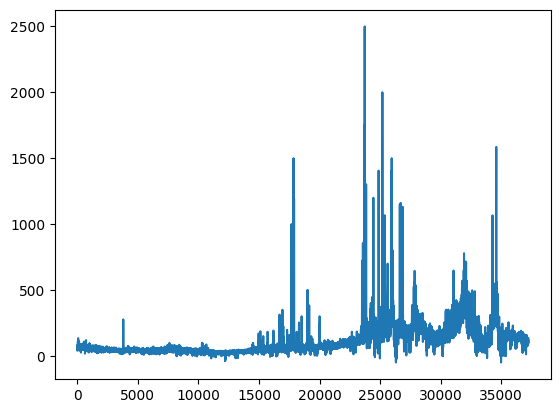

In [15]:
plt.plot(df['Price'])
plt.show()

#### NOTE

* On a high level, there does not appear to any cycling patterns but quite a number of sharp anomalous price rises, especially in the most recent past.
* Further check is required.

## PLOT 2: POWER GENERATION

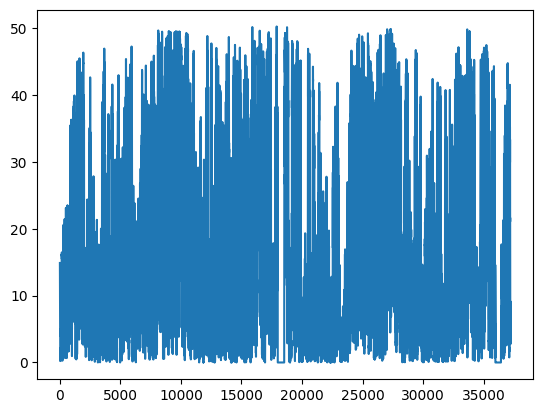

In [16]:
plt.plot(df['Volume_MWh'])
plt.show()

#### NOTE

* On a high level, there seems to be some sort of seasonality in electricity generation.
* Further check is required.

## High Level Statistics

In [17]:
df[["Price", "Volume_MWh"]].describe()

,Price,Volume_MWh
count,37199.000000,37202.000000
mean,101.699219,15.869553
std,100.096202,13.860598
min,-50.080000,0.000000
25%,38.000000,4.350473
50%,60.000000,11.048295
75%,142.495000,25.885298
max,2500.010000,50.284186


### DISTRIBUTION

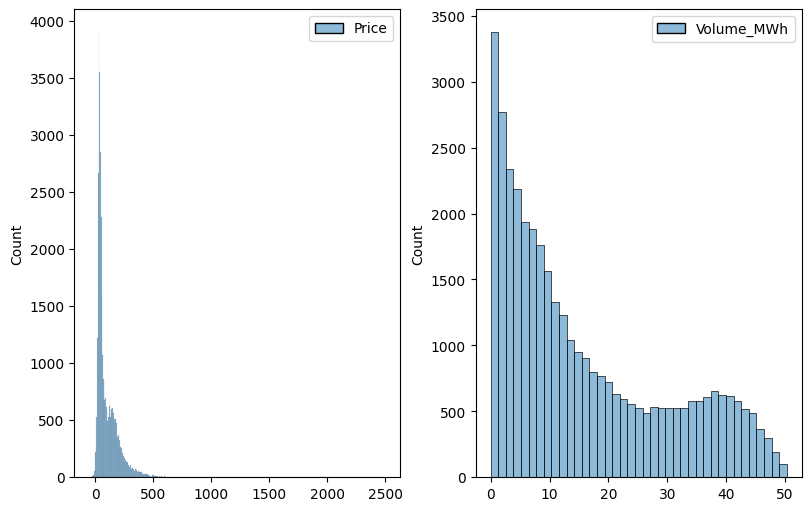

In [19]:
fig, ax = plt.subplots(1,2, figsize=(8,5), constrained_layout=True)
sns.histplot(df[['Price']], ax=ax[0])
sns.histplot(df[['Volume_MWh']], ax=ax[1])
# ax[0].set_xlim([-60,500])
plt.show()

#### NOTE
* The distribution of Price data is not exactly normal. It appears this data can be fit using two Gaussian curves.
* For power generation, the number of 0 counts is the highest. Distribution is not a normal distribution.
* Transformation methods such as Log or Box-Cox require the data to be strictly positive. Hence, for the instances with zero values, a small $\epsilon=0.0001$ will be added to Volume_MWh.

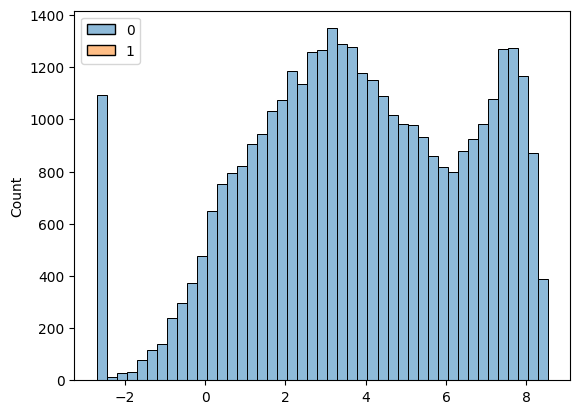

In [22]:
# for time points where power=0.0, the value is replaced by a small number: 0.0001
sns.histplot(scp.stats.boxcox(df['Volume_MWh'].map(lambda x: 0.0001 if x==0.0 or np.isnan(x) else x)))
plt.show()

## DUPLICATES

* Checking for any duplicated timepoint

In [23]:
df.duplicated(subset='UtcDatetime')

0        False
1        False
2        False
3        False
4        False
         ...  
37242    False
37243    False
37244    False
37245    False
37246    False
Length: 37247, dtype: bool

In [25]:
df['UtcDatetime'].duplicated().sum()

np.int64(0)

### NOTE
* No time duplicates

## Missing data

In [8]:
df.isna().value_counts()

UtcDatetime  Price  Volume_MWh
False        False  False         37154
             True   False            48
             False  True             45
Name: count, dtype: int64

#### NOTE
* There are null values in Price and Volume_MWh data

### MISSING TIME STEP

In [9]:
time_diff = np.diff(df['UtcDatetime'])

In [10]:
time_diff

array([3600000000000, 3600000000000, 3600000000000, ..., 3600000000000,
       3600000000000, 3600000000000],
      shape=(37246,), dtype='timedelta64[ns]')

In [12]:
# checking if all difference values are the same and equals to 1 hour
all(time_diff == np.timedelta64(3600000000000))

True

#### NOTE
* No missing time point

### Price null values

In [13]:
df[df['Price'].isna()]

,UtcDatetime,Price,Volume_MWh
1344,2019-02-26 00:00:00,NaN,12.912784
1345,2019-02-26 01:00:00,NaN,8.206155
1346,2019-02-26 02:00:00,NaN,3.648106
1347,2019-02-26 03:00:00,NaN,3.219034
1348,2019-02-26 04:00:00,NaN,1.684564
1349,2019-02-26 05:00:00,NaN,1.111364
1350,2019-02-26 06:00:00,NaN,1.676420
1351,2019-02-26 07:00:00,NaN,2.085795
1352,2019-02-26 08:00:00,NaN,2.024242
1353,2019-02-26 09:00:00,NaN,1.497917


#### NOTE
* Price data missing for 2 days: 2019-02-26 and 2019-03-02

### Volume_MWh null values

In [14]:
df[df['Volume_MWh'].isna()]

,UtcDatetime,Price,Volume_MWh
11688,2020-05-02 00:00:00,17.50,NaN
11689,2020-05-02 01:00:00,16.00,NaN
11690,2020-05-02 02:00:00,15.31,NaN
11691,2020-05-02 03:00:00,14.86,NaN
11692,2020-05-02 04:00:00,15.00,NaN
11693,2020-05-02 05:00:00,15.71,NaN
11694,2020-05-02 06:00:00,10.00,NaN
11695,2020-05-02 07:00:00,20.88,NaN
11696,2020-05-02 08:00:00,26.00,NaN
11697,2020-05-02 09:00:00,27.23,NaN


#### NOTE
* Volume data missing for ~2 days from 2020-05-02 12 am to 2020-05-03 8 pm.

### Handling missing data

* Strategy: given the non-Gaussian distribution, taking the mean of the values of the same date and time from the other years for the missing data

In [26]:
df_copy = df.copy()

In [34]:
def fill_na_func(x, col_to_fill, years_in_data):
    if not np.isnan(x[col_to_fill]):
        return x[col_to_fill]
        
    else:
        datetime_to_fill = x['UtcDatetime']
        median_values = []
        year_to_exclude = datetime_to_fill.year
        remaining_years = years_in_data.copy()
        remaining_years.remove(year_to_exclude)
        for yr in remaining_years:
            
            value = df_copy[col_to_fill][df_copy['UtcDatetime'] == datetime_to_fill.replace(year=yr)].values
            
            if value.size!=0:
                
                median_values.append(value[0])
 
        return np.median(median_values)


#### PRICE

In [35]:
years_in_data = list(range(2019, 2024, 1))

In [36]:
df_copy['Price'] = df_copy.apply(fill_na_func, axis=1, col_to_fill='Price', years_in_data=years_in_data)

In [39]:
# verifying
df_copy['Price'].isna().sum()

np.int64(0)

#### Volume

In [40]:
df_copy['Volume_MWh'] = df_copy.apply(fill_na_func, axis=1, col_to_fill='Volume_MWh', years_in_data=years_in_data)

In [42]:
# verifying
df_copy['Volume_MWh'].isna().sum()

np.int64(0)

#### FINAL CHECK

In [43]:
df_copy.isna().sum()

UtcDatetime    0
Price          0
Volume_MWh     0
dtype: int64

## Correlation

In [44]:
# Pearson: checking for any linear relationship between price and volume
df_corr = df_copy[['Price', 'Volume_MWh']].corr(method='pearson')
df_corr

,Price,Volume_MWh
Price,1.000000,-0.134387
Volume_MWh,-0.134387,1.000000


In [45]:
# Spearman: checking for monotonic relationship between price and volume
df_corr_sp = df_copy[['Price', 'Volume_MWh']].corr(method='spearman')
df_corr_sp

,Price,Volume_MWh
Price,1.000000,-0.153131
Volume_MWh,-0.153131,1.000000


### NOTE
* No correlation between price and volume as expected as the price is determined by several factors such as overall supply and demand, availability of generation sources, weather, hydrological conditions (for hydro-power), wind and solar output and other factors.
* Hence, to predict the expected, P10 and P90 revenue, separate time-series models for Price and Volume_MWh are required.

# PRICE MODEL

## FFT

* Given that the data is a function of time, Fourier Transform can be applied to identify any base cyclical patterns in the data. 

In [46]:
from scipy.fft import fft, ifft, fftfreq

In [47]:
fft_price = fft(df_copy['Price'])

In [48]:
len(fft_price)

37247

In [61]:
# Sampling rate in per hour
sampling_rate = 1

In [50]:
freq_values = fftfreq(len(fft_price), d=1)
freq_values[:10]

array([0.00000000e+00, 2.68477998e-05, 5.36955996e-05, 8.05433995e-05,
       1.07391199e-04, 1.34238999e-04, 1.61086799e-04, 1.87934599e-04,
       2.14782399e-04, 2.41630198e-04])

In [51]:
freq_in_periods = 1/freq_values

/tmp/ipykernel_593442/3993854458.py:1: RuntimeWarning: divide by zero encountered in divide
  freq_in_periods = 1/freq_values


### PLOT 3: FFT of Price

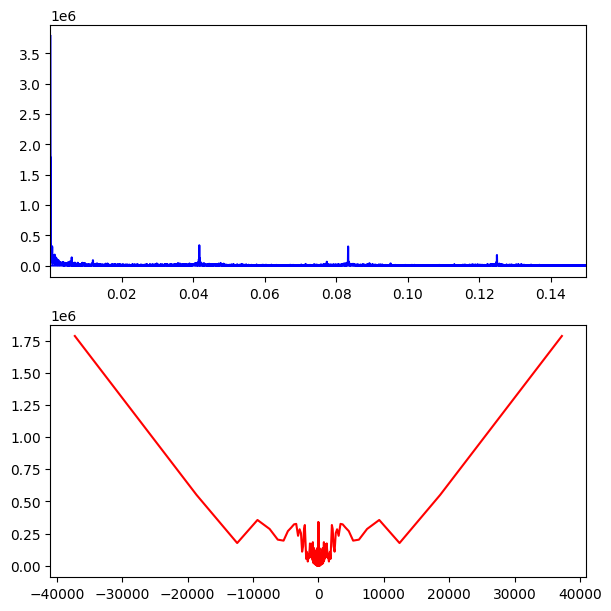

In [106]:
fig, ax = plt.subplots(2,1, figsize=(6, 6), constrained_layout=True)

ax[0].plot(freq_values, np.abs(fft_price), 'b', label="Frequency space")
ax[1].plot(freq_in_periods, np.abs(fft_price), 'r', label="Time space")

ax[0].set_xlim([0.00001, 0.15])
# ax[1].set_xlim([0,20000])
plt.show()

#### NOTE

* There are distinct frequencies in the price cycles

### Fundamental frequency

In [54]:
freq_values_one_side = freq_values[:len(fft_price)//2].copy()
fft_price_one_side = fft_price[:len(fft_price)//2].copy()

#### PLOT 4

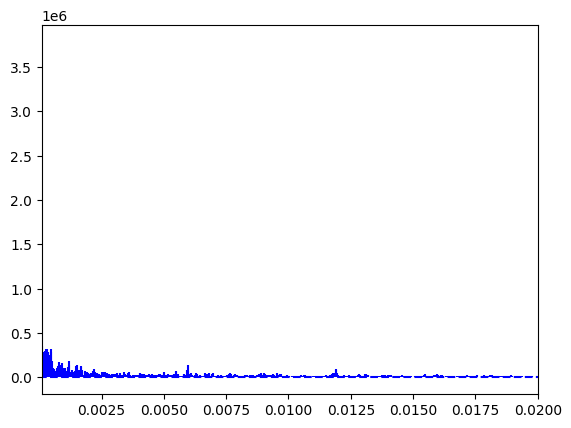

In [95]:
plt.stem(freq_values_one_side, abs(fft_price_one_side), 'b', markerfmt="", basefmt="--b")
plt.xlim(0.0001, 0.02)
plt.show()

In [57]:
freq_0_abs_val = np.max(abs(fft_price_one_side[(freq_values_one_side>0.01) & (freq_values_one_side<0.1)]))
freq_0_abs_val

np.float64(338411.5368824219)

In [58]:
freq_0_idx = np.argwhere(abs(fft_price_one_side) == freq_0_abs_val)
freq_0_idx

array([[1552]])

In [59]:
freq_0 = freq_values_one_side[freq_0_idx[0]]
freq_0

array([0.04166779])

In [60]:
# corresponding time value in hours
time_0 = 1/freq_0
time_0

array([23.99935567])

#### NOTE
* There is a cycling price component in the data with a primary frequency of 24 hours.

#### Second harmonic

In [62]:
freq_1_abs_val = np.max(abs(fft_price_one_side[(freq_values_one_side>0.05) & (freq_values_one_side<0.1)]))
freq_1_abs_val

np.float64(318128.72786269564)

In [63]:
freq_1_idx = np.argwhere(abs(fft_price_one_side) == freq_1_abs_val)
freq_1_idx

array([[3104]])

In [64]:
# confirms the secondary frequency value is twice that of the primary
assert freq_1_idx[0] == freq_0_idx[0]*2

In [65]:
freq_1 = freq_values_one_side[freq_1_idx[0]]
freq_1

array([0.08333557])

In [66]:
freq_1 == freq_0 * 2

array([ True])

#### NOTE

* Secondary frequency is twice that of the primary frequency.
* Other primary frequencies can be extracted through in-depth analysis. However, for this exercise, only this mode is considered.
* A quick test identified 7 days and 89 days (~ 3 months) frequencies

#### Other peaks

In [98]:
freq_2_abs_val = np.max(abs(fft_price_one_side[(freq_values_one_side>0.005) & (freq_values_one_side<0.01)]))
freq_2_abs_val

np.float64(137918.62803856714)

In [114]:
freq_2_idx = np.argwhere(abs(fft_price_one_side) == freq_2_abs_val)
freq_2_idx

array([[222]])

In [115]:
freq_2 = freq_values_one_side[freq_2_idx[0]]
freq_2

array([0.00596021])

In [102]:
# days
time_2 = 1/freq_2/24
time_2

array([6.9908033])

#### NOTE

* Thus two modes - 1 and 7 days - have been identified.
* Other primary frequencies can be extracted through in-depth analysis. However, for this exercise, only these two modes will be considered.

### INVERSE

* From Plot 4, about 7 peaks can be identified corresponding to 1 day cycle and 2 peaks corresponding to 7 days cycle can be identified.

In [112]:
# selecting the indices of 1 day cycle
freq_price_indices_1day = np.arange(freq_0_idx[0][0], len(fft_price_one_side), freq_0_idx[0][0])
freq_price_indices_1day

array([ 1552,  3104,  4656,  6208,  7760,  9312, 10864, 12416, 13968,
       15520, 17072])

In [116]:
# selecting the indices of 1 day cycle
freq_price_indices_7days = np.arange(freq_2_idx[0][0], len(fft_price_one_side), freq_2_idx[0][0])
freq_price_indices_7days

array([  222,   444,   666,   888,  1110,  1332,  1554,  1776,  1998,
        2220,  2442,  2664,  2886,  3108,  3330,  3552,  3774,  3996,
        4218,  4440,  4662,  4884,  5106,  5328,  5550,  5772,  5994,
        6216,  6438,  6660,  6882,  7104,  7326,  7548,  7770,  7992,
        8214,  8436,  8658,  8880,  9102,  9324,  9546,  9768,  9990,
       10212, 10434, 10656, 10878, 11100, 11322, 11544, 11766, 11988,
       12210, 12432, 12654, 12876, 13098, 13320, 13542, 13764, 13986,
       14208, 14430, 14652, 14874, 15096, 15318, 15540, 15762, 15984,
       16206, 16428, 16650, 16872, 17094, 17316, 17538, 17760, 17982,
       18204, 18426])

In [117]:
# appending the indices of 7 days cycle
freq_price_indices = np.concat([freq_price_indices_1day, freq_price_indices_7days])
freq_price_indices

array([ 1552,  3104,  4656,  6208,  7760,  9312, 10864, 12416, 13968,
       15520, 17072,   222,   444,   666,   888,  1110,  1332,  1554,
        1776,  1998,  2220,  2442,  2664,  2886,  3108,  3330,  3552,
        3774,  3996,  4218,  4440,  4662,  4884,  5106,  5328,  5550,
        5772,  5994,  6216,  6438,  6660,  6882,  7104,  7326,  7548,
        7770,  7992,  8214,  8436,  8658,  8880,  9102,  9324,  9546,
        9768,  9990, 10212, 10434, 10656, 10878, 11100, 11322, 11544,
       11766, 11988, 12210, 12432, 12654, 12876, 13098, 13320, 13542,
       13764, 13986, 14208, 14430, 14652, 14874, 15096, 15318, 15540,
       15762, 15984, 16206, 16428, 16650, 16872, 17094, 17316, 17538,
       17760, 17982, 18204, 18426])

In [119]:
# zero all fft price values except for these indices and the corresponding indices of the negative frequencies
fft_price_copy = np.zeros_like(fft_price)

In [120]:
fft_price_copy[freq_price_indices] = fft_price[freq_price_indices]

In [122]:
fft_price_copy[freq_price_indices][:5]

array([-154960.71231855+300848.04458871j,
       -253745.92770978+191882.49441322j,
         56764.95466837-168635.0664865j ,
        106780.51997714 -30660.50947727j,
        -25475.9418148  +58044.87149761j])

In [123]:
fft_price_copy[-1*freq_price_indices] = fft_price[-1*freq_price_indices]

In [127]:
# number of zeros
fft_price_copy[fft_price_copy==0.0].size

37059

In [124]:
# verifying
np.where(fft_price_copy==0.0)[0].size == len(fft_price) - 2 * len(freq_price_indices)

True

In [125]:
# inverse fft
ifft_price = ifft(fft_price_copy)

In [126]:
len(ifft_price)

37247

#### PLOT 5

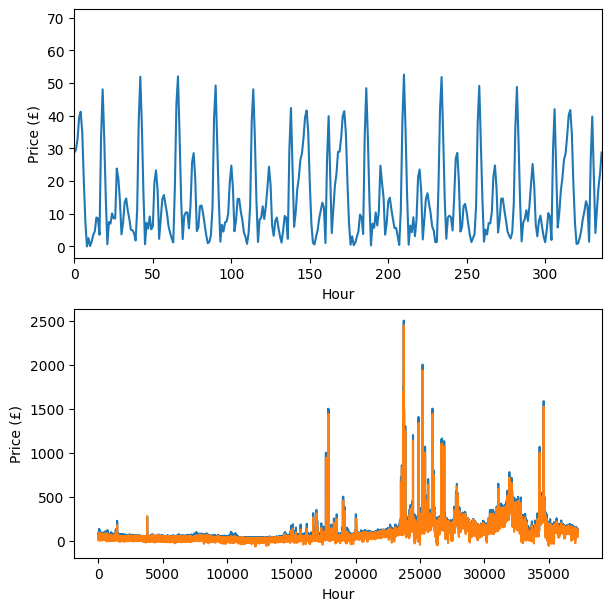

In [133]:
fig, ax = plt.subplots(2,1, figsize=(6,6), constrained_layout=True)
ax[0].plot(abs(ifft_price), label='Primary price mode')
ax[0].set_xlim([0,24*7*2])
ax[1].plot(df_copy['Price'], label="N2EX price")
ax[1].plot(df_copy['Price'] - abs(ifft_price), label="N2EX - base fft price")
[i.set_ylabel('Price (£)') for i in ax]
[i.set_xlabel('Hour') for i in ax]
plt.show()

In [135]:
price_diff = (df['Price'] - abs(ifft_price)).min()
price_diff

np.float64(-65.35905406462345)

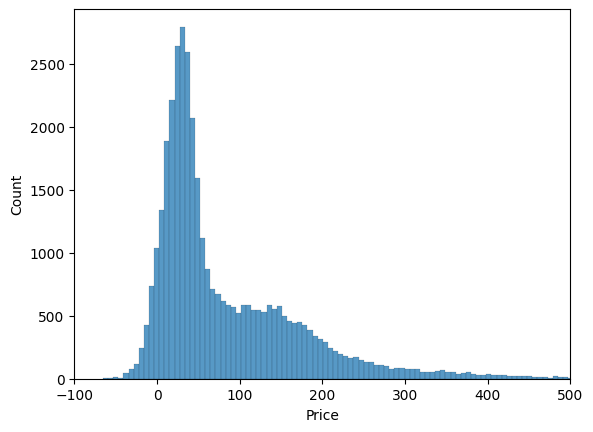

In [146]:
sns.histplot(df['Price'] - abs(ifft_price))
plt.xlim([-100, 500])
plt.show()

### FFT Function: returns BASE PRICE

In [153]:
def generation_fft_func(t, fft_filtered_arr, first_datetime_value):
    """
    Function returns the electricity price calculated from the FFT values for 
    any datetime.

    first_datetime_value: datetime value of the first timepoint in the data. In this case, it
    is "2019-01-01 00:00:00"
    """
    
    _N = len(fft_filtered_arr)

    time_factor = 2*np.pi*np.arange(0, _N)/_N

    time_diff = t - first_datetime_value
    
    n =  int(time_diff.total_seconds()/3600)
    # must be in hours

    return abs(np.dot(fft_filtered_arr, np.exp(-1j * (_N - n) * time_factor))/_N)

#### TEST EXAMPLE

In [148]:
df_copy.iloc[0]

UtcDatetime    2019-01-01 00:00:00
Price                        60.12
Volume_MWh               14.889867
Name: 0, dtype: object

In [151]:
# example
test = generation_fft_func(df_copy.iloc[1,0], fft_price_copy, df_copy.iloc[0,0])
test

np.float64(29.59072410260874)

#### FFT BASE PRICE

In [158]:
df_copy['FFT_Base_Price'] = df_copy['UtcDatetime'].map(lambda x: generation_fft_func(x,
                                                                                    fft_price_copy,
                                                                                    df_copy.iloc[0,0]
                                                                                    )
                                                      )

In [159]:
df_copy.head(5)

,UtcDatetime,Price,Volume_MWh,FFT_Base_Price
0,2019-01-01 00:00:00,60.12,14.889867,28.729931
1,2019-01-01 01:00:00,55.76,14.162405,29.590724
2,2019-01-01 02:00:00,46.23,13.943371,32.823482
3,2019-01-01 03:00:00,44.10,13.288542,39.385040
4,2019-01-01 04:00:00,44.41,10.449148,41.219280


## REGRESSION MODELS

* We could use GradientBoostingRegressor to develop forecasting models on the Price data not captured by FFT for calculating Expected, P10 and P90 revenues.

### Data processing

#### Convert time to Sine and Cosine features

In [160]:
df_copy['time_cosine'] = np.cos(df_copy['UtcDatetime'].map(lambda x:x.value))

In [161]:
df_copy['time_sine'] = np.sin(df_copy['UtcDatetime'].map(lambda x:x.value))

In [162]:
df_copy.head(5)

,UtcDatetime,Price,Volume_MWh,FFT_Base_Price,time_cosine,time_sine
0,2019-01-01 00:00:00,60.12,14.889867,28.729931,0.213888,0.976858
1,2019-01-01 01:00:00,55.76,14.162405,29.590724,0.970275,0.242004
2,2019-01-01 02:00:00,46.23,13.943371,32.823482,0.647588,-0.761991
3,2019-01-01 03:00:00,44.10,13.288542,39.385040,-0.395303,-0.918551
4,2019-01-01 04:00:00,44.41,10.449148,41.219280,-0.998565,-0.053561


### Data preparation for training

#### NOTE

* As N2EX prices are day-ahead prices, the models will be designed to predict prices 24h in the future

In [163]:
df_price = pd.DataFrame()
df_price['Price'] = df_copy['Price']-df_copy['FFT_Base_Price'] # removing the base fft price
df_price['time_cosine'] = df_copy['time_cosine']
df_price['time_sine'] = df_copy['time_sine']
df_price

,Price,time_cosine,time_sine
0,31.390069,0.213888,0.976858
1,26.169276,0.970275,0.242004
2,13.406518,0.647588,-0.761991
3,4.714960,-0.395303,-0.918551
4,3.190720,-0.998565,-0.053561
...,...,...,...
37242,109.366348,0.553580,0.832796
37243,117.179156,0.991988,-0.126334
37244,93.539201,0.327175,-0.944964
37245,76.190497,-0.701500,-0.712670


In [164]:
train_x = df_price.iloc[:-24, :]
train_x

,Price,time_cosine,time_sine
0,31.390069,0.213888,0.976858
1,26.169276,0.970275,0.242004
2,13.406518,0.647588,-0.761991
3,4.714960,-0.395303,-0.918551
4,3.190720,-0.998565,-0.053561
...,...,...,...
37218,94.222819,-0.807612,0.589714
37219,103.771259,0.169892,0.985463
37220,97.758676,0.958454,0.285247
37221,79.439070,0.681089,-0.732201


In [165]:
train_y = df_price.iloc[24:, 0]
train_y

24        41.847183
25        43.841280
26        41.349632
27        24.687957
28        27.123890
            ...    
37242    109.366348
37243    117.179156
37244     93.539201
37245     76.190497
37246     92.598085
Name: Price, Length: 37223, dtype: float64

In [166]:
# splitting to train and test data
train_test_split_ratio = 0.8
split_size = int(len(train_x)*train_test_split_ratio)
split_size

29778

In [167]:
test_x = train_x[split_size:].to_numpy()
test_y = train_y[split_size:].to_numpy()

In [168]:
test_x.shape, test_y.shape

((7445, 3), (7445,))

In [169]:
train_x = train_x[:split_size].to_numpy()
train_y = train_y[:split_size].to_numpy()

In [170]:
train_x.shape, train_y.shape

((29778, 3), (29778,))

### Expected Prices

* Given the several anomalous price rises, using 50th percentile or median for expected prices

In [172]:
from sklearn.ensemble import GradientBoostingRegressor

In [173]:
model_price_expected = GradientBoostingRegressor(loss='quantile',
                                                alpha=0.5,
                                                n_estimators=1000
                                                )

In [174]:
model_price_expected.fit(train_x, train_y)

GradientBoostingRegressor(alpha=0.5, loss='quantile', n_estimators=1000)

#### Train data score

In [175]:
model_price_expected.score(train_x, train_y)

0.7400723946796426

#### Test data score

In [176]:
model_price_expected.score(test_x, test_y)

0.6899641533175359

#### NOTE
* The $R^{2}$ score is reasonable.

### 10th percentile Prices

In [177]:
model_price_p10 = GradientBoostingRegressor(loss='quantile',
                                            alpha=0.1,
                                            n_estimators=1000
                                            )

In [178]:
model_price_p10.fit(train_x, train_y)

GradientBoostingRegressor(alpha=0.1, loss='quantile', n_estimators=1000)

#### Train data score

In [179]:
model_price_p10.score(train_x, train_y)

0.5699866014999386

#### Test data score

In [180]:
model_price_p10.score(test_x, test_y)

0.20722502522528596

* The $R^{2}$ score is poor on test data.

### 90th percentile Prices

In [181]:
model_price_p90 = GradientBoostingRegressor(loss='quantile',
                                            alpha=0.9,
                                            n_estimators=1000
                                            )

In [182]:
model_price_p90.fit(train_x, train_y)

GradientBoostingRegressor(loss='quantile', n_estimators=1000)

#### Train data score

In [183]:
model_price_p90.score(train_x, train_y)

0.6144794144979113

#### Test data score

In [184]:
model_price_p90.score(test_x, test_y)

0.509664094886604

* The $R^{2}$ score is ok.

#### NOTE

* Hyperparameter optimisation could probably increase the $R^{2}$ to an extent.
* However, other factors that are not considered here such as total electricity supply, demand, gas prices, etc will play a significant role in estimating the prices

## PREDICTION

* FFT + GradientBoosting Model

In [186]:
last_time_point = df_copy.iloc[-1,0]
last_time_point

Timestamp('2023-04-01 22:00:00')

In [187]:
# range for which prediction is required
time_range = datetime.fromisoformat("2024-03-31 23:00:00") - last_time_point
time_range

Timedelta('365 days 01:00:00')

In [188]:
total_num_hours = time_range.total_seconds()/3600
total_num_hours

8761.0

In [228]:
df_price_23_24 = pd.DataFrame(columns=['UtcDatetime', 'time_cosine', 'time_sine', 'FFT_Base_Price', 
                                       'Model_Expected', 'Model_P10', 'Model_P90']
                             )

In [229]:
df_price_23_24['UtcDatetime']=[last_time_point + timedelta(hours=i) for i in range(1, int(total_num_hours)+1)]

In [230]:
df_price_23_24.head(5)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90
0,2023-04-01 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-04-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-04-02 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-04-02 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-04-02 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [231]:
df_price_23_24.tail(5)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90
8756,2024-03-31 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN
8757,2024-03-31 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN
8758,2024-03-31 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN
8759,2024-03-31 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN
8760,2024-03-31 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [232]:
df_price_23_24['time_cosine'] = np.cos(df_price_23_24['UtcDatetime'].map(lambda x: x.value))
df_price_23_24['time_sine'] = np.sin(df_price_23_24['UtcDatetime'].map(lambda x: x.value))

In [233]:
df_price_23_24.head(5)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90
0,2023-04-01 23:00:00,-0.141987,0.989868,NaN,NaN,NaN,NaN
1,2023-04-02 00:00:00,0.823948,0.566665,NaN,NaN,NaN,NaN
2,2023-04-02 01:00:00,0.873544,-0.486745,NaN,NaN,NaN,NaN
3,2023-04-02 02:00:00,-0.048356,-0.998830,NaN,NaN,NaN,NaN
4,2023-04-02 03:00:00,-0.916478,-0.400085,NaN,NaN,NaN,NaN


#### Prediction function

In [256]:
def price_model_prediction_function(last_time_val, 
                                    model,
                                   feature
                                  ):    

    # gbr model
    x_features = np.array([[last_time_val[feature], last_time_val['time_cosine'], last_time_val['time_sine']]])
    model_price = model.predict(x_features)
    
    return model_price

#### Example

In [235]:
df_price.tail(5)

,Price,time_cosine,time_sine
37242,109.366348,0.553580,0.832796
37243,117.179156,0.991988,-0.126334
37244,93.539201,0.327175,-0.944964
37245,76.190497,-0.701500,-0.712670
37246,92.598085,-0.950014,0.312207


In [257]:
price_model_prediction_function(
                         last_time_val=df_price.iloc[-24],
                         model=model_price_expected,
                          feature='Price'
                         )

array([50.9073182])

#### SEED DATA

* Selecting the latest 24 hour data to initiate prediciton

In [239]:
df_price_23_24.columns

Index(['UtcDatetime', 'time_cosine', 'time_sine', 'FFT_Base_Price',
       'Model_Expected', 'Model_P10', 'Model_P90'],
      dtype='object')

In [240]:
df_copy.columns

Index(['UtcDatetime', 'Price', 'Volume_MWh', 'FFT_Base_Price', 'time_cosine',
       'time_sine'],
      dtype='object')

In [241]:
df_price_seed = df_copy[['UtcDatetime', 'time_cosine', 'time_sine', 'Price', 'FFT_Base_Price']][-24:].copy()
df_price_seed.reset_index(drop=True, inplace=True)
df_price_seed

,UtcDatetime,time_cosine,time_sine,Price,FFT_Base_Price
0,2023-03-31 23:00:00,-0.995161,-0.098262,80.00,26.355530
1,2023-04-01 00:00:00,-0.529834,0.848101,82.00,28.475163
2,2023-04-01 01:00:00,0.524738,0.851264,82.10,32.901324
3,2023-04-01 02:00:00,0.995732,-0.092291,81.32,38.958025
4,2023-04-01 03:00:00,0.359341,-0.933206,80.08,41.314748
5,2023-04-01 04:00:00,-0.676685,-0.736273,88.26,35.340173
6,2023-04-01 05:00:00,-0.960148,0.279493,92.19,20.080992
7,2023-04-01 06:00:00,-0.175800,0.984426,100.01,7.249158
8,2023-04-01 07:00:00,0.804061,0.594547,100.04,1.325633
9,2023-04-01 08:00:00,0.889699,-0.456547,111.57,0.228446


In [242]:
df_price_seed['Model_Expected'] = df_price_seed['Price']-df_price_seed['FFT_Base_Price']
df_price_seed.drop(columns=["Price"], inplace=True)
df_price_seed.head(5)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected
0,2023-03-31 23:00:00,-0.995161,-0.098262,26.355530,53.644470
1,2023-04-01 00:00:00,-0.529834,0.848101,28.475163,53.524837
2,2023-04-01 01:00:00,0.524738,0.851264,32.901324,49.198676
3,2023-04-01 02:00:00,0.995732,-0.092291,38.958025,42.361975
4,2023-04-01 03:00:00,0.359341,-0.933206,41.314748,38.765252


In [243]:
df_price_seed["Model_P10"]=np.zeros(len(df_price_seed))
df_price_seed["Model_P90"]=np.zeros(len(df_price_seed))
df_price_seed.tail(5)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90
19,2023-04-01 18:00:00,0.553580,0.832796,22.273652,109.366348,0.0,0.0
20,2023-04-01 19:00:00,0.991988,-0.126334,4.110844,117.179156,0.0,0.0
21,2023-04-01 20:00:00,0.327175,-0.944964,11.450799,93.539201,0.0,0.0
22,2023-04-01 21:00:00,-0.701500,-0.712670,18.819503,76.190497,0.0,0.0
23,2023-04-01 22:00:00,-0.950014,0.312207,22.161915,92.598085,0.0,0.0


In [244]:
df_price_23_24.head(5)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90
0,2023-04-01 23:00:00,-0.141987,0.989868,NaN,NaN,NaN,NaN
1,2023-04-02 00:00:00,0.823948,0.566665,NaN,NaN,NaN,NaN
2,2023-04-02 01:00:00,0.873544,-0.486745,NaN,NaN,NaN,NaN
3,2023-04-02 02:00:00,-0.048356,-0.998830,NaN,NaN,NaN,NaN
4,2023-04-02 03:00:00,-0.916478,-0.400085,NaN,NaN,NaN,NaN


In [245]:
# rconcatinating the two dataframes 
df_price_concat = pd.concat([df_price_seed, df_price_23_24], ignore_index=True)
df_price_concat.head(25)

/tmp/ipykernel_593442/4205335422.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_price_concat = pd.concat([df_price_seed, df_price_23_24], ignore_index=True)


,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90
0,2023-03-31 23:00:00,-0.995161,-0.098262,26.355530,53.644470,0.0,0.0
1,2023-04-01 00:00:00,-0.529834,0.848101,28.475163,53.524837,0.0,0.0
2,2023-04-01 01:00:00,0.524738,0.851264,32.901324,49.198676,0.0,0.0
3,2023-04-01 02:00:00,0.995732,-0.092291,38.958025,42.361975,0.0,0.0
4,2023-04-01 03:00:00,0.359341,-0.933206,41.314748,38.765252,0.0,0.0
5,2023-04-01 04:00:00,-0.676685,-0.736273,35.340173,52.919827,0.0,0.0
6,2023-04-01 05:00:00,-0.960148,0.279493,20.080992,72.109008,0.0,0.0
7,2023-04-01 06:00:00,-0.175800,0.984426,7.249158,92.760842,0.0,0.0
8,2023-04-01 07:00:00,0.804061,0.594547,1.325633,98.714367,0.0,0.0
9,2023-04-01 08:00:00,0.889699,-0.456547,0.228446,111.341554,0.0,0.0


#### Prediction

In [258]:
# prediction from 2023-04-01 23:00:00
for row in df_price_concat.iloc[24:].itertuples():

    # fft model
    df_price_concat.loc[row.Index, 'FFT_Base_Price'] = generation_fft_func(row.UtcDatetime, 
                                                                           fft_price_copy, 
                                                                           df_copy.iloc[0,0]
                                                                          )

    # print(row)
    df_price_concat.loc[row.Index, 'Model_Expected'] = price_model_prediction_function(last_time_val=df_price_concat.iloc[row.Index-24],
                                                                                        model=model_price_expected,
                                                                                         feature='Model_Expected' 
                                                                                )
    df_price_concat.loc[row.Index, 'Model_P10'] = price_model_prediction_function(last_time_val=df_price_concat.iloc[row.Index-24],
                                                                                model=model_price_p10,
                                                                                feature='Model_Expected'
                                                                                 )
    
    df_price_concat.loc[row.Index, 'Model_P90'] = price_model_prediction_function(
                                                                                last_time_val=df_price_concat.iloc[row.Index-24],
                                                                                model=model_price_p90,
                                                                                feature='Model_Expected'                                        
                                                                                )

In [259]:
df_price_concat['Price_Expected'] = df_price_concat['Model_Expected'] + df_price_concat['FFT_Base_Price']
df_price_concat['Price_P10'] = df_price_concat['Model_P10'] + df_price_concat['FFT_Base_Price']
df_price_concat['Price_P90'] = df_price_concat['Model_P90'] + df_price_concat['FFT_Base_Price']
df_price_concat.head(30)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90,Price_Expected,Price_P10,Price_P90
0,2023-03-31 23:00:00,-0.995161,-0.098262,26.355530,53.644470,0.000000,0.000000,80.000000,26.355530,26.355530
1,2023-04-01 00:00:00,-0.529834,0.848101,28.475163,53.524837,0.000000,0.000000,82.000000,28.475163,28.475163
2,2023-04-01 01:00:00,0.524738,0.851264,32.901324,49.198676,0.000000,0.000000,82.100000,32.901324,32.901324
3,2023-04-01 02:00:00,0.995732,-0.092291,38.958025,42.361975,0.000000,0.000000,81.320000,38.958025,38.958025
4,2023-04-01 03:00:00,0.359341,-0.933206,41.314748,38.765252,0.000000,0.000000,80.080000,41.314748,41.314748
5,2023-04-01 04:00:00,-0.676685,-0.736273,35.340173,52.919827,0.000000,0.000000,88.260000,35.340173,35.340173
6,2023-04-01 05:00:00,-0.960148,0.279493,20.080992,72.109008,0.000000,0.000000,92.190000,20.080992,20.080992
7,2023-04-01 06:00:00,-0.175800,0.984426,7.249158,92.760842,0.000000,0.000000,100.010000,7.249158,7.249158
8,2023-04-01 07:00:00,0.804061,0.594547,1.325633,98.714367,0.000000,0.000000,100.040000,1.325633,1.325633
9,2023-04-01 08:00:00,0.889699,-0.456547,0.228446,111.341554,0.000000,0.000000,111.570000,0.228446,0.228446


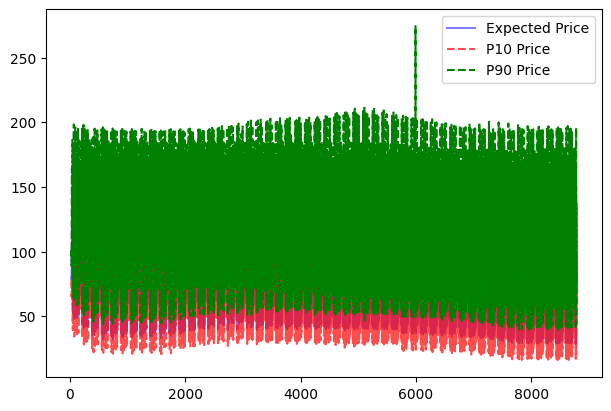

In [260]:
fig, ax = plt.subplots(1,1, figsize = (6,4), constrained_layout=True)

ax.plot(df_price_concat['Price_Expected'].iloc[24:], 'b', alpha=0.5, label='Expected Price')
ax.plot(df_price_concat['Price_P10'].iloc[24:], 'r--', alpha=0.7, label='P10 Price')
ax.plot(df_price_concat['Price_P90'].iloc[24:], 'g--', label='P90 Price')
ax.legend()

plt.show()

# VOLUME MODEL

## NOTE:
* The above price model can be used to estimate the Expected, P10 and P90 revenue.
* The MWh generation is expected from the customer. However, in the absence of the same, a volume generation model on the lines of Price model will be developed.

## BASIC MODEL 1

* A simple model is to take the required quantile for a year using data from the same time and date of previous years.

In [261]:
def percentile_func(x, percentile, years_in_data):
   

    datetime_to_fill = x['UtcDatetime']
    percentiles_arr = []
  
    for yr in years_in_data:
        
        value = df_copy['Volume_MWh'][df_copy['UtcDatetime'] == datetime_to_fill.replace(year=yr)].values
        # print(value)
        if value.size!=0:
            percentiles_arr.append(value[0])
    
    return np.percentile(percentiles_arr, q=percentile)


In [262]:
# dropping the historic data
df_price_concat.drop(index=range(0,24), inplace=True)
df_price_concat.reset_index(inplace=True, drop=True)
df_price_concat.head(5)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90,Price_Expected,Price_P10,Price_P90
0,2023-04-01 23:00:00,-0.141987,0.989868,28.729931,50.907318,35.735943,70.652083,79.637250,64.465874,99.382014
1,2023-04-02 00:00:00,0.823948,0.566665,29.590724,50.876619,35.692180,71.166818,80.467343,65.282904,100.757542
2,2023-04-02 01:00:00,0.873544,-0.486745,32.823482,45.776477,31.793233,63.392855,78.599959,64.616715,96.216337
3,2023-04-02 02:00:00,-0.048356,-0.998830,39.385040,40.861423,27.330888,56.267088,80.246463,66.715928,95.652128
4,2023-04-02 03:00:00,-0.916478,-0.400085,41.219280,37.864883,25.035082,47.743542,79.084163,66.254362,88.962821


In [266]:
years_in_data

[2019, 2020, 2021, 2022, 2023, 2024]

In [264]:
years_in_data.append(2024)
years_in_data

[2019, 2020, 2021, 2022, 2023, 2024, 2024]

In [270]:
df_final_m1 = df_price_concat.copy()
df_final_m1.head(5)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90,Price_Expected,Price_P10,Price_P90
0,2023-04-01 23:00:00,-0.141987,0.989868,28.729931,50.907318,35.735943,70.652083,79.637250,64.465874,99.382014
1,2023-04-02 00:00:00,0.823948,0.566665,29.590724,50.876619,35.692180,71.166818,80.467343,65.282904,100.757542
2,2023-04-02 01:00:00,0.873544,-0.486745,32.823482,45.776477,31.793233,63.392855,78.599959,64.616715,96.216337
3,2023-04-02 02:00:00,-0.048356,-0.998830,39.385040,40.861423,27.330888,56.267088,80.246463,66.715928,95.652128
4,2023-04-02 03:00:00,-0.916478,-0.400085,41.219280,37.864883,25.035082,47.743542,79.084163,66.254362,88.962821


### Prediction Function

In [271]:
import calendar

In [274]:
def percentile_func(x, percentile, years_in_data):
    """
    Function takes the datetime at which the power generation estimate is required.
    It uses the previous years values at the same day-month and hour and returns the
    desired percentile.    
    """

    datetime_to_fill = x['UtcDatetime']
    percentiles_arr = []
    leap_years = list(filter(lambda x: calendar.isleap(x), years_in_data))
  
    if datetime_to_fill.day==29 and datetime_to_fill.month==2:
        
        years_in_data = list(filter(lambda x: calendar.isleap(x), years_in_data))

    
    for yr in years_in_data:
        
        value = df_copy['Volume_MWh'][df_copy['UtcDatetime'] == datetime_to_fill.replace(year=yr)].values
        # print(value)
        if value.size!=0:
            percentiles_arr.append(value[0])

    return np.percentile(percentiles_arr, q=percentile)


#### Example

In [275]:
percentile_func(df_copy.iloc[0], percentile=10, years_in_data=years_in_data)

np.float64(7.877916666666667)

### Prediction

In [277]:
df_final_m1["MWh_Estimate"] = df_final_m1.apply(percentile_func, axis=1, percentile=50, years_in_data=years_in_data)

In [ ]:
# we could also estimate the 10th and 90th percentiles
# df_final_m1["MWh_10"] = df_final_m1.apply(percentile_func, axis=1, percentile=10, years_in_data=years_in_data)
# df_final_m1["MWh_90"] = df_final_m1.apply(percentile_func, axis=1, percentile=90, years_in_data=years_in_data)

In [280]:
df_final_m1.head(10)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90,Price_Expected,Price_P10,Price_P90,MWh_Estimate
0,2023-04-01 23:00:00,-0.141987,0.989868,28.729931,50.907318,35.735943,70.652083,79.637250,64.465874,99.382014,8.797254
1,2023-04-02 00:00:00,0.823948,0.566665,29.590724,50.876619,35.692180,71.166818,80.467343,65.282904,100.757542,7.592045
2,2023-04-02 01:00:00,0.873544,-0.486745,32.823482,45.776477,31.793233,63.392855,78.599959,64.616715,96.216337,6.304782
3,2023-04-02 02:00:00,-0.048356,-0.998830,39.385040,40.861423,27.330888,56.267088,80.246463,66.715928,95.652128,6.300852
4,2023-04-02 03:00:00,-0.916478,-0.400085,41.219280,37.864883,25.035082,47.743542,79.084163,66.254362,88.962821,5.007150
5,2023-04-02 04:00:00,-0.765356,0.643608,35.000182,50.876619,35.707397,69.844118,85.876801,70.707579,104.844300,5.799811
6,2023-04-02 05:00:00,0.236943,0.971523,20.075429,72.684689,52.270043,89.041910,92.760118,72.345472,109.117339,8.575663
7,2023-04-02 06:00:00,0.975730,0.218977,7.330501,94.520995,71.477216,135.345377,101.851496,78.807717,142.675878,8.620644
8,2023-04-02 07:00:00,0.629376,-0.777101,0.005895,96.611988,71.197007,136.718391,96.617883,71.202901,136.724285,7.003409
9,2023-04-02 08:00:00,-0.416927,-0.908940,2.526538,110.412474,78.426255,161.644461,112.939012,80.952794,164.170999,7.919081


In [283]:
df_final_m1.drop(columns=['P10', 'P90'], inplace=True)

In [284]:
df_final_m1['Expected'] = df_final_m1['Price_Expected']*df_final_m1['MWh_Estimate']
df_final_m1['P10'] = df_final_m1['Price_P10']*df_final_m1['MWh_Estimate']
df_final_m1['P90'] = df_final_m1['Price_P90']*df_final_m1['MWh_Estimate']
df_final_m1.head(5)

,UtcDatetime,time_cosine,time_sine,FFT_Base_Price,Model_Expected,Model_P10,Model_P90,Price_Expected,Price_P10,Price_P90,MWh_Estimate,Expected,P10,P90
0,2023-04-01 23:00:00,-0.141987,0.989868,28.729931,50.907318,35.735943,70.652083,79.637250,64.465874,99.382014,8.797254,700.589096,567.122658,874.288800
1,2023-04-02 00:00:00,0.823948,0.566665,29.590724,50.876619,35.692180,71.166818,80.467343,65.282904,100.757542,7.592045,610.911726,495.630775,764.955840
2,2023-04-02 01:00:00,0.873544,-0.486745,32.823482,45.776477,31.793233,63.392855,78.599959,64.616715,96.216337,6.304782,495.555620,407.394316,606.623047
3,2023-04-02 02:00:00,-0.048356,-0.998830,39.385040,40.861423,27.330888,56.267088,80.246463,66.715928,95.652128,6.300852,505.621108,420.367208,602.689931
4,2023-04-02 03:00:00,-0.916478,-0.400085,41.219280,37.864883,25.035082,47.743542,79.084163,66.254362,88.962821,5.007150,395.986235,331.745503,445.450157


### Total Expected Revenue

In [404]:
df_final_m1["Expected"].sum()

np.float64(11589733.276134493)

### Total P10 Revenue

In [405]:
df_final_m1["P10"].sum()

np.float64(8835462.849202843)

### Total P90 Revenue

In [406]:
df_final_m1["P90"].sum()

np.float64(15497669.603276914)

In [290]:
df_final_m1[["UtcDatetime","FFT_Base_Price", "Price_Expected", "Price_P10", "Price_P90", "MWh_Estimate","P10", "Expected", "P90"]].to_csv("wind_energy_revenue_forecast_model1.csv")

## FFT MODEL 2

In [291]:
fft_mwh = fft(df_copy['Volume_MWh'])

In [322]:
# Sampling rate in per second
sampling_rate = 1/3600

In [326]:
freq_values = fftfreq(len(fft_price), d=1/sampling_rate)
freq_values[:10]

array([0.00000000e+00, 7.45772217e-09, 1.49154443e-08, 2.23731665e-08,
       2.98308887e-08, 3.72886109e-08, 4.47463330e-08, 5.22040552e-08,
       5.96617774e-08, 6.71194996e-08])

In [338]:
freq_in_periods = 1/freq_values*sampling_rate

/tmp/ipykernel_593442/627703714.py:1: RuntimeWarning: divide by zero encountered in divide
  freq_in_periods = 1/freq_values*sampling_rate


### PLOT 6: FFT of Generation

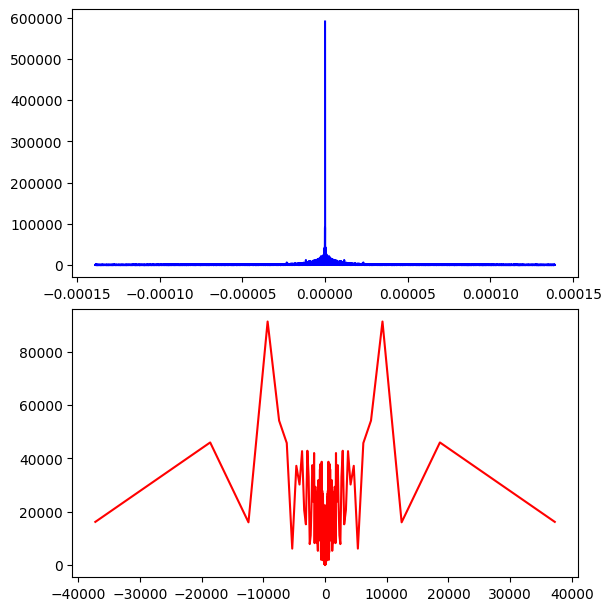

In [339]:
fig, ax = plt.subplots(2,1, figsize=(6, 6), constrained_layout=True)

ax[0].plot(freq_values, np.abs(fft_mwh), 'b', label="Frequency space")
ax[1].plot(freq_in_periods, np.abs(fft_mwh), 'r', label="Time space")

# ax[0].set_xlim([0.00000001, 0.0002])
# ax[1].set_xlim([1,5000])
# ax[1].set_ylim([90000,100000])
plt.show()

#### NOTE

* PLOT 2 shows there are some cycling patterns.
* However, the fft appears to be noisy with a couple of tiny peaks visible near  ($10^{-7} Hz$). 
* Selecting these peaks for preliminary investigation.

### Strongest frequency

In [340]:
freq_values_one_side = freq_values[:len(fft_mwh)//2].copy()
freq_periods_one_side = freq_in_periods[:len(fft_mwh)//2].copy()
fft_mwh_one_side = fft_mwh[:len(fft_mwh)//2].copy()

In [341]:
freq_0_abs_val = np.max(abs(fft_mwh_one_side[(freq_periods_one_side>8000) & (freq_periods_one_side<10000)]))
freq_0_abs_val

np.float64(91273.02766437038)

In [342]:
freq_0_idx = np.argwhere(abs(fft_mwh_one_side) == freq_0_abs_val)
freq_0_idx

array([[4]])

In [343]:
freq_0_time = freq_periods_one_side[freq_0_idx[0]]
freq_0_time

array([9311.75])

In [344]:
freq_0 = freq_values_one_side[freq_0_idx[0]]
freq_0

array([2.98308887e-08])

In [346]:
# corresponding time value in days
time_0 = 1/freq_0*sampling_rate/24
time_0

array([387.98958333])

#### NOTE
* This correspond to a frequency of ~388 days.

### INVERSE: Strongest frequency

* There are two peaks

In [347]:
freq_0_idx[0]

array([4])

In [348]:
freq_mwh_indices = np.arange(2,6,2)
freq_mwh_indices

array([2, 4])

In [349]:
# zero all fft mwh values except for these indices and the corresponding indices of the negative frequencies
fft_mwh[-1*freq_mwh_indices]

array([-42511.55458377-17458.9540821j ,  58801.06500271-69808.31135021j])

In [350]:
fft_mwh[freq_mwh_indices]

array([-42511.55458377+17458.9540821j ,  58801.06500271+69808.31135021j])

In [351]:
fft_mwh_copy = np.zeros_like(fft_mwh)

In [352]:
fft_mwh_copy[freq_mwh_indices] = fft_mwh[freq_mwh_indices]

In [353]:
fft_mwh_copy[freq_mwh_indices]

array([-42511.55458377+17458.9540821j ,  58801.06500271+69808.31135021j])

In [354]:
fft_mwh_copy[-1*freq_mwh_indices] = fft_mwh[-1*freq_mwh_indices]

In [355]:
# verifying
np.where(fft_mwh_copy==0.0)[0].size == len(fft_mwh) - 2 * len(freq_mwh_indices)

True

In [356]:
ifft_mwh = ifft(fft_mwh_copy)

In [357]:
len(ifft_mwh)

37247

#### PLOT 7

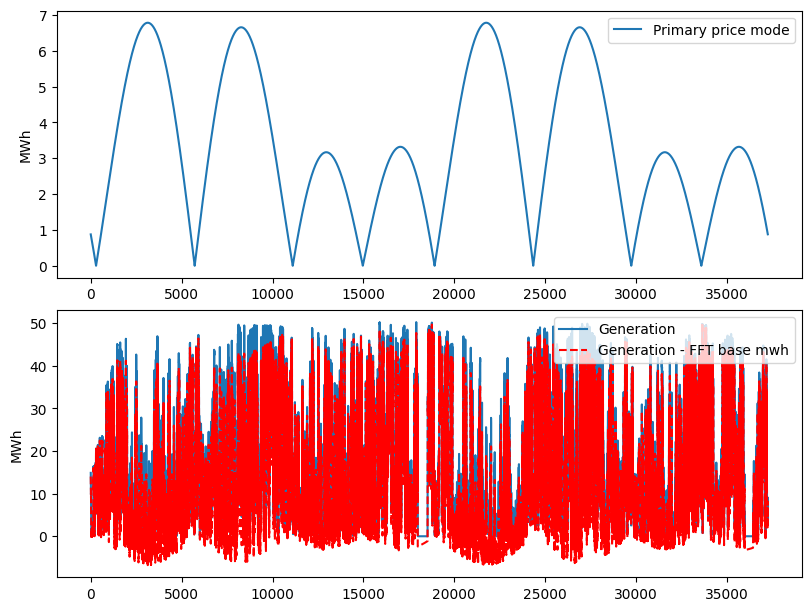

In [358]:
fig, ax = plt.subplots(2,1, figsize=(8,6), constrained_layout=True)
ax[0].plot(abs(ifft_mwh), label='Primary price mode')
# ax[0].set_xlim([0,48])
ax[1].plot(df_copy['Volume_MWh'], label="Generation")
ax[1].plot(df_copy['Volume_MWh'] - abs(ifft_mwh), 'r--', label="Generation - FFT base mwh")
[i.legend() for i in ax]
[i.set_ylabel('MWh') for i in ax]
plt.show()

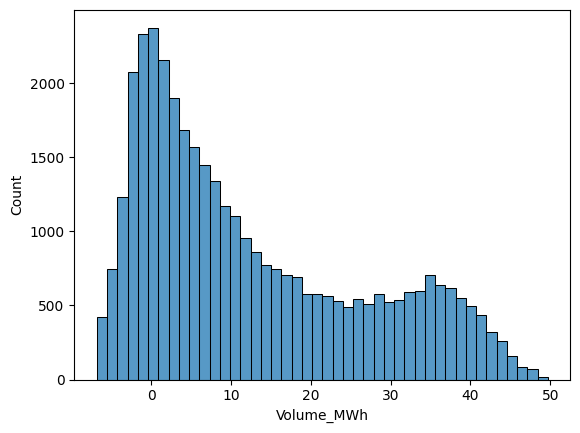

In [359]:
sns.histplot(df_copy['Volume_MWh'] - abs(ifft_mwh))
plt.show()

#### NOTE
* Clearly, the chosen frequencies are not sufficient as the bottom graph in PLOT 7 still shows certain patterns.
* This is corroborated by the above histogram which still shows a non-normal distribution.
* Therefore, selecting all frequencies below $10^{-6} Hz$ and zeroing all frequencies beyond this point and inverting. 

### INVERSE: $<=10^{-6} Hz$ 

In [360]:
fft_mwh_copy = np.copy(fft_mwh)

In [361]:
threshold_freq = 10**(-6)

In [362]:
freq_values_copy =  np.copy(freq_values)
freq_values_copy[freq_values_copy > threshold_freq]=0.0
freq_values_copy[freq_values_copy < -1*threshold_freq]=0.0

In [366]:
# highest frequency
highest_pos_freq = freq_values_copy.max()
highest_pos_freq

np.float64(9.993347711821681e-07)

In [378]:
# in days
lowest_time_period = 1/highest_pos_freq * sampling_rate/24
lowest_time_period

np.float64(11.581778606965175)

In [368]:
highest_neg_freq = freq_values_copy.min()
highest_neg_freq

np.float64(-9.993347711821681e-07)

In [369]:
fft_mwh_copy[freq_values > threshold_freq] = 0.0
fft_mwh_copy[freq_values < -1*threshold_freq] = 0.0

In [370]:
ifft_volume = ifft(fft_mwh_copy)

In [371]:
# number of non zero frequencies
non_zero_frequencies = len(fft_mwh_copy) - fft_mwh_copy[fft_mwh_copy==0.0].size
non_zero_frequencies

269

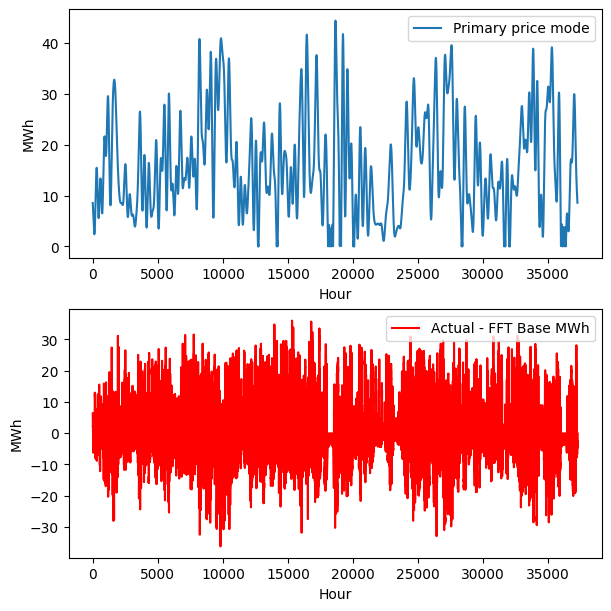

In [375]:
fig, ax = plt.subplots(2,1, figsize=(6,6), constrained_layout=True)
ax[0].plot(abs(ifft_volume), label='Primary price mode')

ax[1].plot(df_copy['Volume_MWh'] - abs(ifft_volume), 'r', label="Actual - FFT Base MWh")
[i.legend() for i in ax]
[i.set_ylabel('MWh') for i in ax]
[i.set_xlabel('Hour') for i in ax]
plt.show()

### DIFFERENCE PLOT

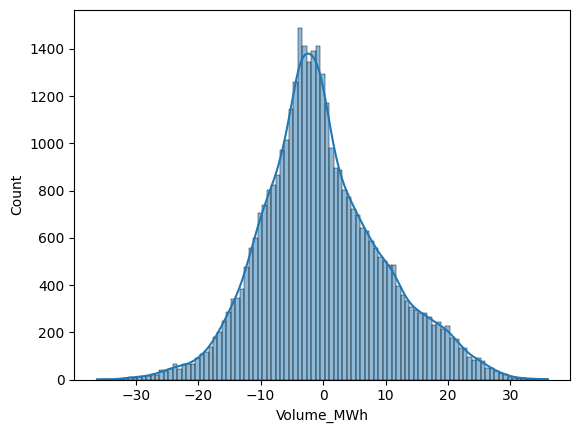

In [376]:
sns.histplot(df_copy['Volume_MWh'] - abs(ifft_volume), kde=True)
plt.show()

#### NOTE

* Given the close-to-normal distribution of the power generation component, the Power generation can be modelled using a combination of 269 frequencies with the smallest cycle time period corresponding to ~ 12 days.
* The remaining data can be sampled.

### Distribution sampling function

In [379]:
from sklearn.neighbors import KernelDensity

In [380]:
kde = KernelDensity(bandwidth=1.0, kernel='gaussian')

In [381]:
volume_fft_subtracted = df_copy['Volume_MWh'].to_numpy() - abs(ifft_volume)
volume_fft_subtracted[:5]

array([6.36267329, 5.69073414, 5.52745667, 4.92862346, 2.14547112])

In [382]:
kde_fit = kde.fit(volume_fft_subtracted[..., np.newaxis])

In [384]:
sampled_data = kde_fit.sample(n_samples=len(df_final_m1))

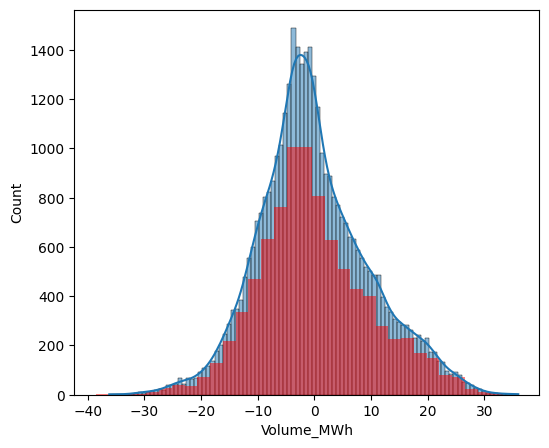

In [385]:
fig, ax = plt.subplots(1,1, figsize=(6,5))
sns.histplot(df_copy['Volume_MWh'] - abs(ifft_volume), kde=True)
# sns.histplot(sampled_data, kde=True, ax=ax, color='r')
ax.hist(sampled_data, bins=32, color='r', alpha=0.5)
plt.show()

#### NOTE
* The sampled data distribution is similar to that of the original subtracted data

### PREDICTION

In [386]:
df_final_fft = df_final_m1[["UtcDatetime"]].copy()
df_final_fft.head(5)

,UtcDatetime
0,2023-04-01 23:00:00
1,2023-04-02 00:00:00
2,2023-04-02 01:00:00
3,2023-04-02 02:00:00
4,2023-04-02 03:00:00


In [387]:
df_final_fft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8761 entries, 0 to 8760
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   UtcDatetime  8761 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 68.6 KB


In [388]:
# Power generation from FFT
df_final_fft["MWh_Estimate"] = df_final_m1['UtcDatetime'].map(lambda x: generation_fft_func(x, 
                                             fft_filtered_arr=fft_mwh_copy, 
                                             first_datetime_value=df_copy.iloc[0,0]
                                            ))

In [389]:
# Sampling from the distribution
df_final_fft["MWh_Estimate"] = df_final_fft["MWh_Estimate"] + sampled_data.flatten()

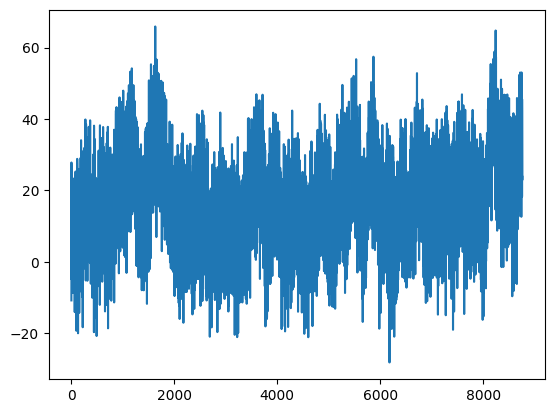

In [390]:
plt.plot(df_final_fft["MWh_Estimate"])
plt.show()

In [391]:
df_final_fft[["Price_Expected", "Price_P10", "Price_P90"]] = df_final_m1[["Price_Expected", "Price_P10", "Price_P90"]].copy()

In [393]:
df_final_fft["Expected"] = df_final_fft["Price_Expected"]*df_final_fft["MWh_Estimate"]
df_final_fft['P10'] = df_final_fft['Price_P10']*df_final_fft['MWh_Estimate']
df_final_fft['P90'] = df_final_fft['Price_P90']*df_final_fft['MWh_Estimate']

### Total Expected Revenue

In [394]:
df_final_fft['Expected'].sum()

np.float64(11947808.554255232)

### Total P10 Revenue

In [395]:
df_final_fft['P10'].sum()

np.float64(9110180.868508833)

### Total P90 Revenue

In [396]:
df_final_fft['P90'].sum()

np.float64(15970427.38450477)

In [403]:
df_final_fft[["UtcDatetime","Price_Expected","Price_P10", "Price_P90", "MWh_Estimate","Expected","P10","P90"]].to_csv("wind_energy_revenue_forecast_fft_model2.csv")

## Validation

* Sense checking by calculating the expected, P10, P90 revenues from historic data

In [398]:
def historic_revenue(start_year, end_year):

    """
    Function returns the total revenue from April of start_year to March of end_year 
    """
    assert end_year > start_year
    
    start_time = datetime.fromisoformat(f"{str(start_year)}-01-04 00:00:00")
    end_time =  datetime.fromisoformat(f"{str(end_year)}-03-31 23:00:00")

    bool_mask = (df_copy["UtcDatetime"] >= start_time) & (df_copy["UtcDatetime"] <= end_time)

    revenue = (df_copy["Price"][bool_mask] * df_copy["Volume_MWh"][bool_mask]).sum()
    
    return revenue

In [399]:
hist_revenues = [historic_revenue(yr, yr+1) for yr in range(2019, 2023)]
hist_revenues

[np.float64(7135975.658292141),
 np.float64(7210874.097701705),
 np.float64(22743589.130605116),
 np.float64(28359866.202837124)]

### Using percentiles for estimation

In [400]:
# Expected
expected_revenue = np.percentile(hist_revenues, q=50)
expected_revenue

np.float64(14977231.614153411)

In [401]:
# P10
p10_revenue = np.percentile(hist_revenues, q=10)
p10_revenue

np.float64(7158445.19011501)

In [402]:
# P90
p90_revenue = np.percentile(hist_revenues, q=90)
p90_revenue

np.float64(26674983.081167523)

### NOTE

* The sum obtained from the two models are of the same order of magnitude.